In [1]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Loading Data

In [2]:
df = pd.read_pickle("../../data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [3]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [4]:
df_train.head(10)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."
39126,43226,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
29963,32875,Health Care Equipment & Services,"[0.026474293,0.06491662,-0.040673323,-0.082956..."
18502,20188,Materials,"[0.039364863,0.04066422,-0.03719509,0.00711928..."
12513,13644,Utilities,"[0.010298253,0.046219144,-0.012434618,0.005032..."
11381,12349,"Pharmaceuticals, Biotechnology & Life Sciences","[0.0026364033,-0.04669612,-0.016867306,-0.0214..."
11397,12348,Semiconductors & Semiconductor Equipment,"[0.041281756,-0.13804789,-0.02782986,0.0361299..."
5096,5160,"Pharmaceuticals, Biotechnology & Life Sciences","[0.028728371,0.013093453,-0.011429115,-0.02804..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

In [5]:
# Fit the label encoder to the classes (industry names)
from sklearn.preprocessing import LabelEncoder

# creates empty encoder
encoder = LabelEncoder()
# scancs industry, sorts them uniquely alphabetically and assigns a number to each industry starting 0
encoder.fit(df_train.industry)

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](25,)","['Automobiles & Components','Banks','Capital Goods',..., 'Telecommunication Services','Transportation','Utilities']"


In [6]:
y_train = encoder.transform(df_train.industry)
y_val =  encoder.transform(df_val.industry)

# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

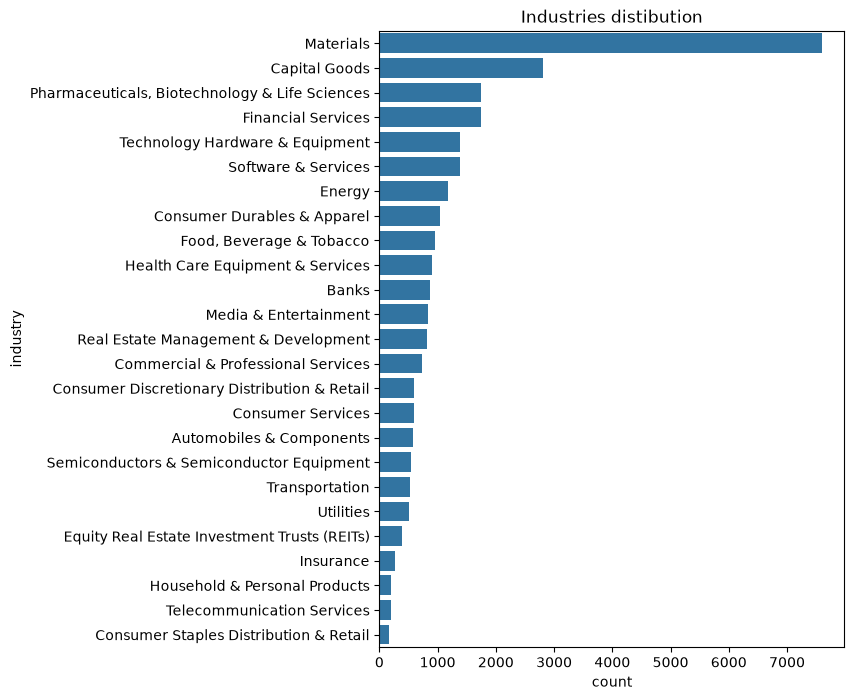

In [7]:
# Plot the class distribution or provide a table that shows how many times each class (industry) appears
# Describe your findings


plt.figure(figsize=(6,8))
sns.countplot(data=df_train, y="industry", order = df_train['industry'].value_counts().index)
plt.title("Industries distibution")
plt.tight_layout
plt.show()


### PCA - Dimensionality reduction and visualization

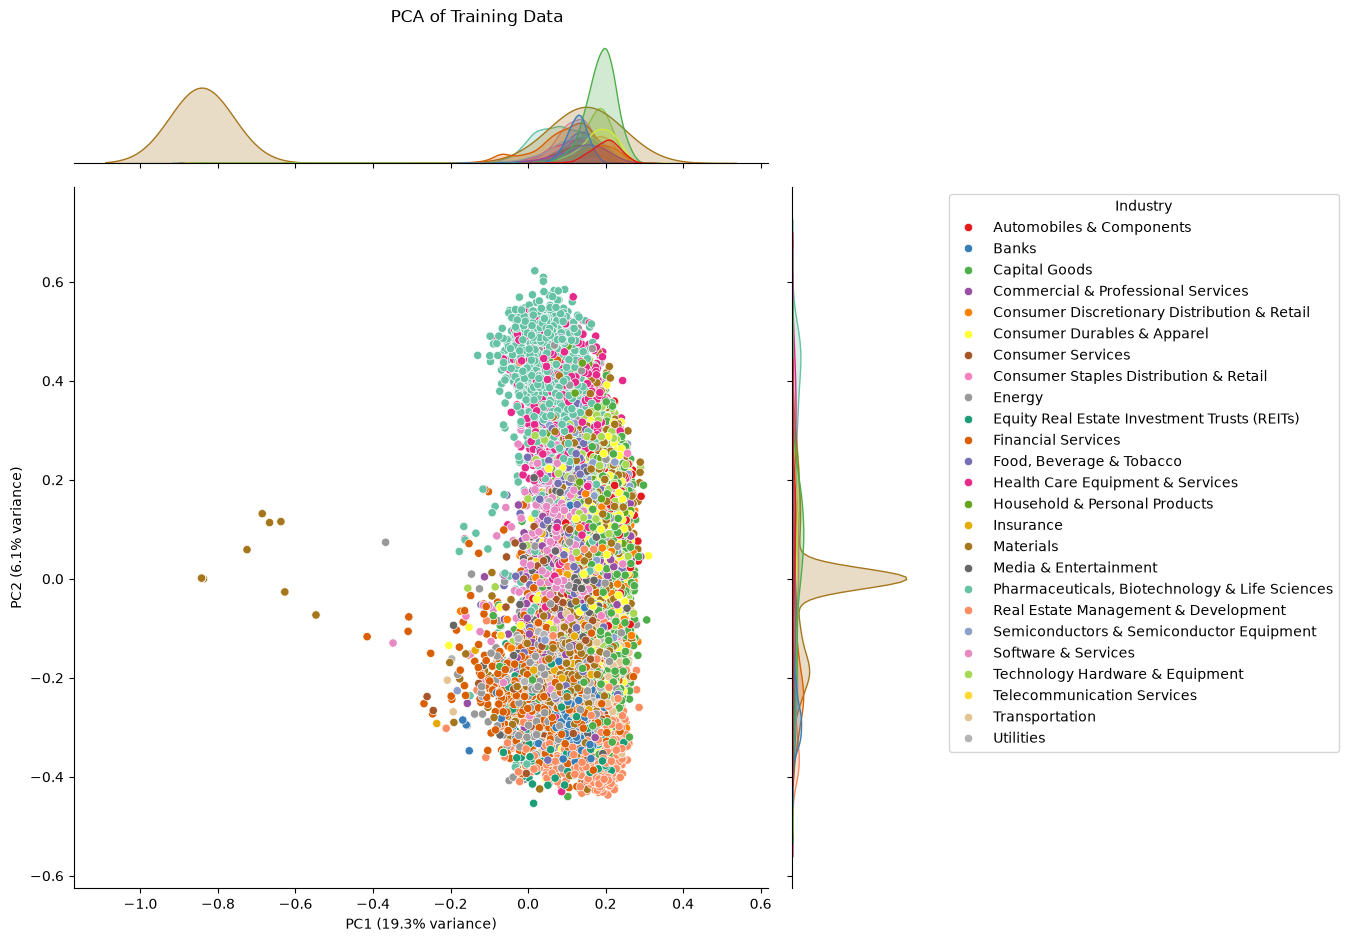

In [8]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
var = pca.explained_variance_ratio_

industries = df_train["industry"].values
levels = sorted(df_train["industry"].unique())

# 9 + 8 + 8 = 25 distinct colors from built-in palettes
colors = (sns.color_palette("Set1", 9)
          + sns.color_palette("Dark2", 8)
          + sns.color_palette("Set2", 8))
palette = dict(zip(levels, colors))

g = sns.jointplot(
    x=X_train_pca[:, 0], y=X_train_pca[:, 1],
    hue=industries, hue_order=levels, palette=palette,
    height=9, ratio=5,
)
g.set_axis_labels(f"PC1 ({var[0]:.1%} variance)", f"PC2 ({var[1]:.1%} variance)")
g.figure.suptitle("PCA of Training Data", y=1.02)
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(1.25, 1), title="Industry")
plt.show()

# investigation of duplicates

In [9]:
pca_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
pca_df["industry"] = industries

# round to avoid tiny float differences, then count stacked points
stacked = (pca_df.round(4)
           .groupby(["PC1", "PC2"])
           .size()
           .sort_values(ascending=False))
print(stacked.head(10))

mask = (pca_df["PC1"].between(-0.9, -0.8)) & (pca_df["PC2"].between(-0.05, 0.05))
print(mask.sum(), "points in region")

region_rows = df_train.iloc[np.where(mask)[0]]
region_rows.head(20)

PC1      PC2    
-0.8423   0.0014    3941
-0.8376  -0.0000     107
-0.0723  -0.2299      17
-0.0698  -0.1144       8
-0.0736  -0.2285       8
-0.0634  -0.3507       7
-0.0356  -0.2145       6
-0.6276  -0.0265       5
-0.0131  -0.2664       4
-0.0513  -0.3065       4
dtype: int64
4048 points in region


,id,industry,business_description_embedding
39126,43226,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
12942,14107,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
34202,37695,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
28953,31763,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
21682,23731,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
31003,34034,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
8777,9576,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
29015,31819,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
17700,19345,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."
31330,34368,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223..."


### Duplicate Deletion of embeddings and ids

In [10]:
print(df_train.business_description_embedding.duplicated().sum())
print(df.business_description_embedding.duplicated().sum())


4140
4578


In [11]:
# --- Remove duplicate embeddings, then rebuild everything derived from df ---
n_before = len(df)

# check: are there identical embeddings with different industry labels?
conflicts = df.groupby("business_description_embedding")["industry"].nunique()
print("Embeddings with >1 industry label:", (conflicts > 1).sum())

df = df.drop_duplicates(subset="business_description_embedding").reset_index(drop=True)
print(f"Rows: {n_before} -> {len(df)} ({n_before - len(df)} duplicates removed)")

# re-split on clean data (dedup BEFORE split -> no train/val leakage)
df_train, df_val = train_test_split(df, test_size=0.1, random_state=42)

X_train = np.array(df_train.business_description_embedding.apply(ast.literal_eval).tolist())
X_val   = np.array(df_val.business_description_embedding.apply(ast.literal_eval).tolist())

encoder = LabelEncoder().fit(df_train.industry)
y_train = encoder.transform(df_train.industry)
y_val   = encoder.transform(df_val.industry)

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)


Embeddings with >1 industry label: 17
Rows: 31706 -> 27128 (4578 duplicates removed)
(24415, 768) (24415,) (2713, 768) (2713,)


In [12]:
encoder = LabelEncoder().fit(df_train.industry)
y_train = encoder.transform(df_train.industry)
y_val   = encoder.transform(df_val.industry)

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)


(24415, 768) (24415,) (2713, 768) (2713,)


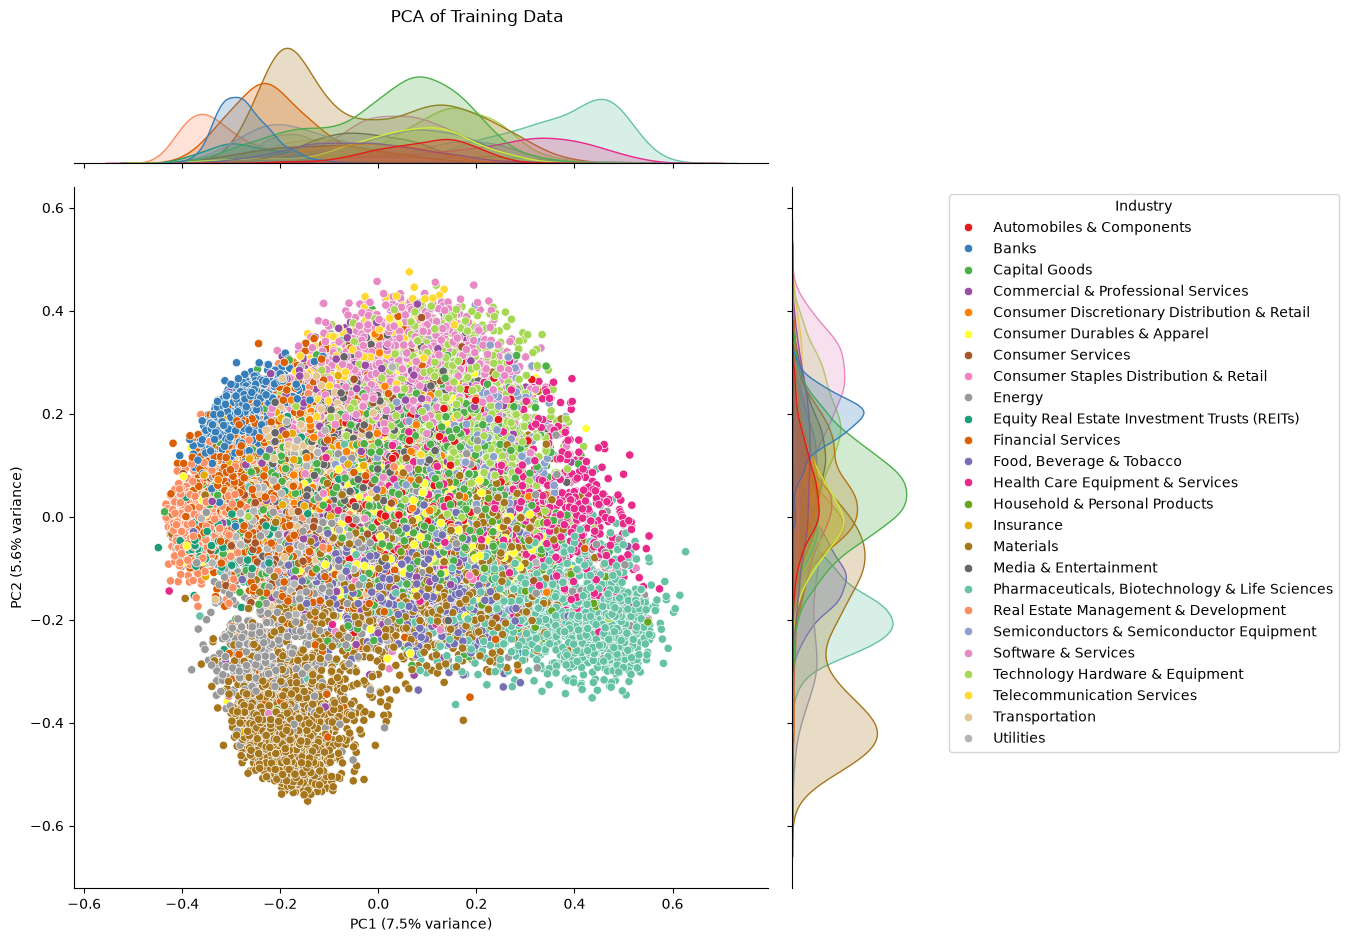

In [13]:
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train)
var = pca.explained_variance_ratio_

industries = df_train["industry"].values
levels = sorted(df_train["industry"].unique())

# 9 + 8 + 8 = 25 distinct colors from built-in palettes
colors = (sns.color_palette("Set1", 9)
          + sns.color_palette("Dark2", 8)
          + sns.color_palette("Set2", 8))
palette = dict(zip(levels, colors))

g = sns.jointplot(
    x=X_train_pca[:, 0], y=X_train_pca[:, 1],
    hue=industries, hue_order=levels, palette=palette,
    height=9, ratio=5,
)
g.set_axis_labels(f"PC1 ({var[0]:.1%} variance)", f"PC2 ({var[1]:.1%} variance)")
g.figure.suptitle("PCA of Training Data", y=1.02)
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(1.25, 1), title="Industry")
plt.show()

# PCA2 vs PCA3

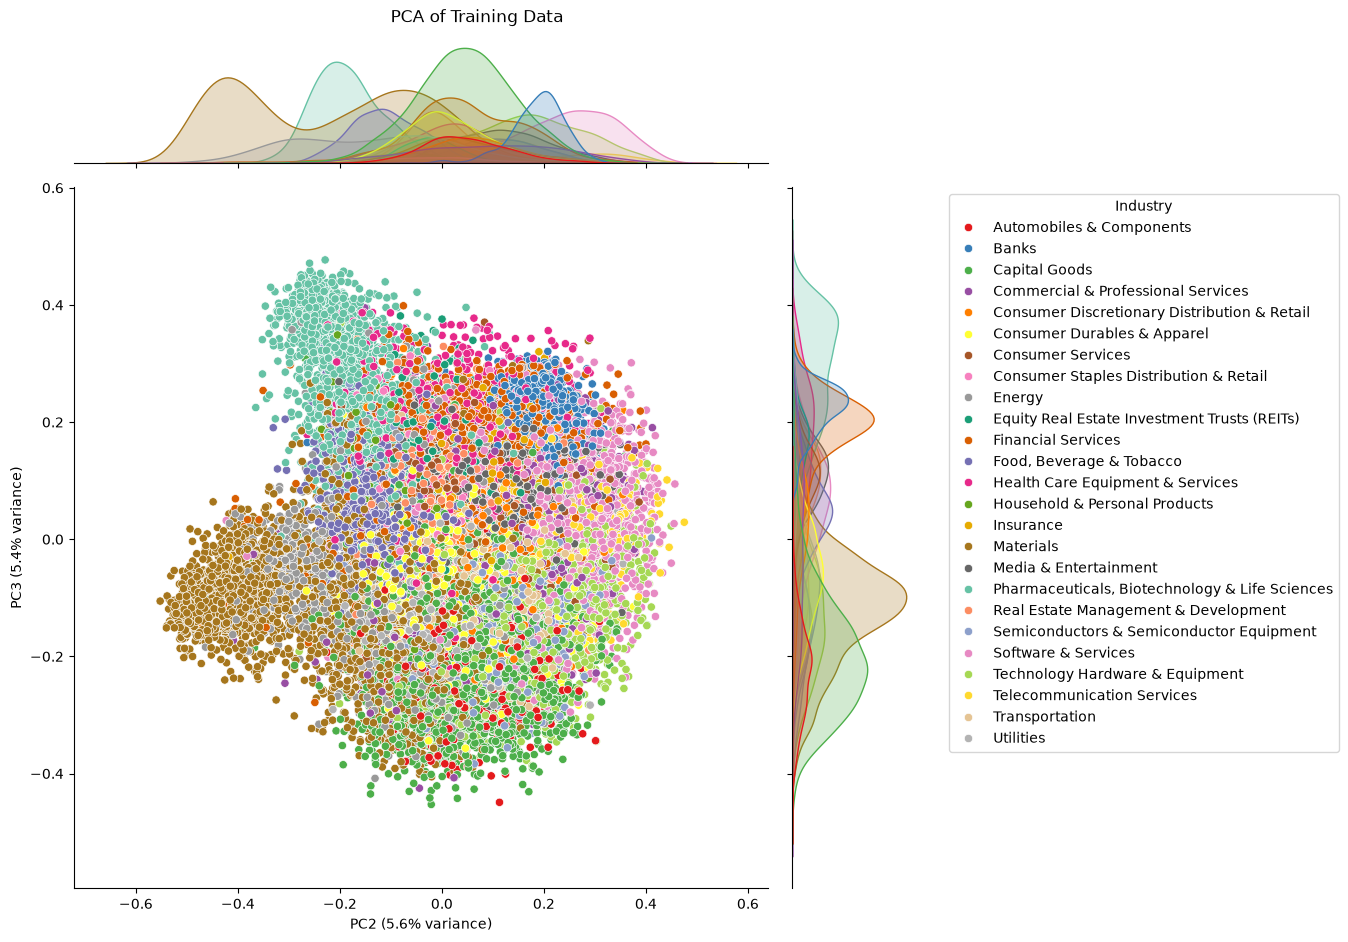

In [14]:
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train)
var = pca.explained_variance_ratio_

industries = df_train["industry"].values
levels = sorted(df_train["industry"].unique())

# 9 + 8 + 8 = 25 distinct colors from built-in palettes
colors = (sns.color_palette("Set1", 9)
          + sns.color_palette("Dark2", 8)
          + sns.color_palette("Set2", 8))
palette = dict(zip(levels, colors))

g = sns.jointplot(
    x=X_train_pca[:, 1], y=X_train_pca[:, 2],
    hue=industries, hue_order=levels, palette=palette,
    height=9, ratio=5,
)
g.set_axis_labels(f"PC2 ({var[1]:.1%} variance)", f"PC3 ({var[2]:.1%} variance)")
g.figure.suptitle("PCA of Training Data", y=1.02)
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(1.25, 1), title="Industry")
plt.show()

## PCA3 vs PCA4

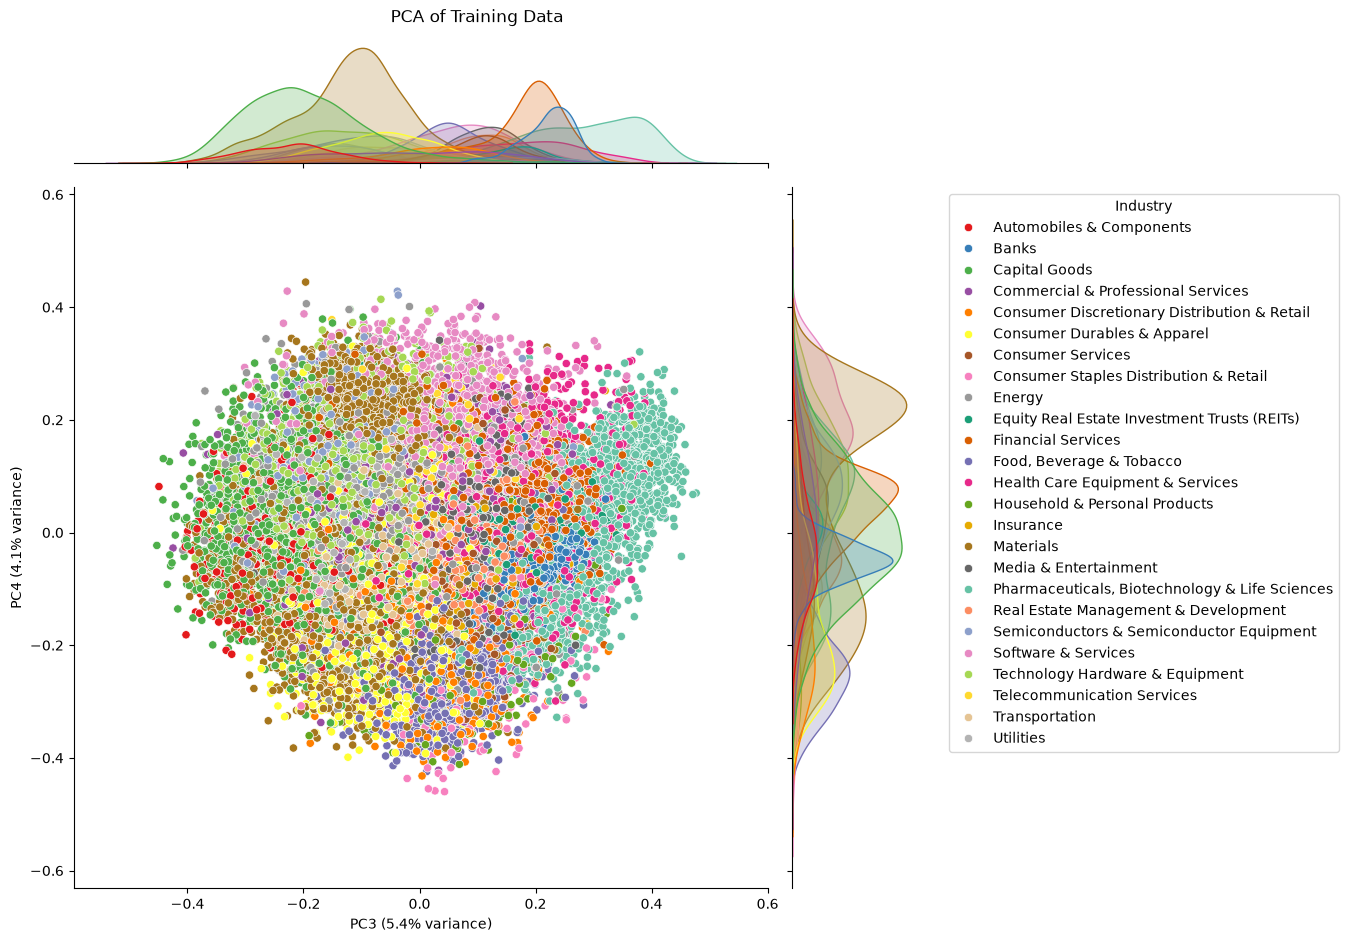

In [15]:
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train)
var = pca.explained_variance_ratio_

industries = df_train["industry"].values
levels = sorted(df_train["industry"].unique())

# 9 + 8 + 8 = 25 distinct colors from built-in palettes
colors = (sns.color_palette("Set1", 9)
          + sns.color_palette("Dark2", 8)
          + sns.color_palette("Set2", 8))
palette = dict(zip(levels, colors))

g = sns.jointplot(
    x=X_train_pca[:, 2], y=X_train_pca[:, 3],
    hue=industries, hue_order=levels, palette=palette,
    height=9, ratio=5,
)
g.set_axis_labels(f"PC3 ({var[2]:.1%} variance)", f"PC4 ({var[3]:.1%} variance)")
g.figure.suptitle("PCA of Training Data", y=1.02)
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(1.25, 1), title="Industry")
plt.show()

## PCA5 vs PCA6

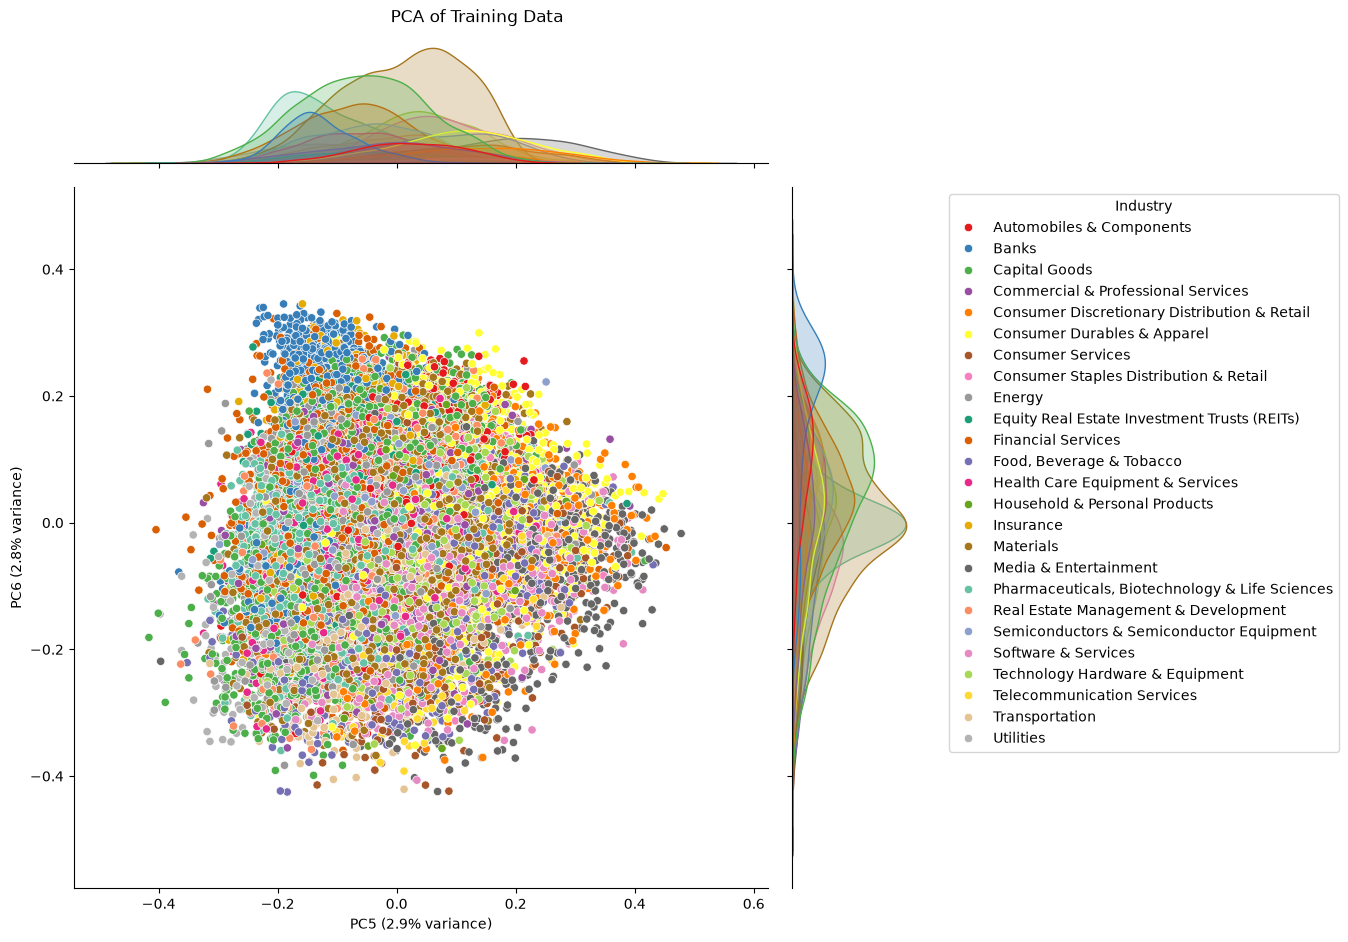

In [16]:
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train)
var = pca.explained_variance_ratio_

industries = df_train["industry"].values
levels = sorted(df_train["industry"].unique())

# 9 + 8 + 8 = 25 distinct colors from built-in palettes
colors = (sns.color_palette("Set1", 9)
          + sns.color_palette("Dark2", 8)
          + sns.color_palette("Set2", 8))
palette = dict(zip(levels, colors))

g = sns.jointplot(
    x=X_train_pca[:, 4], y=X_train_pca[:, 5],
    hue=industries, hue_order=levels, palette=palette,
    height=9, ratio=5,
)
g.set_axis_labels(f"PC5 ({var[4]:.1%} variance)", f"PC6 ({var[5]:.1%} variance)")
g.figure.suptitle("PCA of Training Data", y=1.02)
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(1.25, 1), title="Industry")
plt.show()

# Analysis of PCA Plots

PCA1 and PCA2 have explain only around 25% of the variance found in our data, when looking at the distribution of the different classes phen plotting them together, no major groups can be discovered, but we can see that the workers are plotted very narrowly together. When Plotting other dimensions together, we can see how Worker clearly creates a distinguised group, but still a lotof the worker samples being plotted in the main blob, showing that industries defined as worker probably include a broader spectrum.

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [ ]:
logReg = LogisticRegression(max_iter=1000, random_state=0).fit(X_train, y_train)
y_pred = logReg.predict(X_val)


In [36]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_val, y_pred))
print("macro" , f1_score(y_val, y_pred, average="macro"))
print("weighed" , f1_score(y_val, y_pred, average="weighted"))

0.72981938813122
macro 0.6971726995525959
weighed 0.7237881807106838


In [29]:
values, counts = np.unique(y_val, return_counts=True)
counts.max() / counts.sum()

np.float64(0.13932915591596018)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.74      0.78        65
           1       0.96      0.97      0.97       102
           2       0.63      0.72      0.67       323
           3       0.53      0.25      0.34        84
           4       0.75      0.68      0.71        71
           5       0.73      0.66      0.69       113
           6       0.83      0.75      0.79        69
           7       0.70      0.27      0.39        26
           8       0.69      0.55      0.61       136
           9       0.81      0.76      0.78        50
          10       0.72      0.80      0.76       168
          11       0.81      0.82      0.81       109
          12       0.73      0.79      0.76       117
          13       0.56      0.31      0.40        29
          14       0.90      0.88      0.89        32
          15       0.82      0.87      0.84       378
          16       0.67      0.70      0.69        86
          17       0.74    

## kNN

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier().fit(X_train, y_train)
y_pred_knn = knn.predict(X_val)

In [44]:
print(accuracy_score(y_val, y_pred_knn))
print(f1_score(y_val, y_pred_knn, average="macro"))
print(f1_score(y_val, y_pred_knn, average="weighted"))

0.7113896056026539
0.6761587914600821
0.7055402509300793


# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of an industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- Designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

## Scoring

Your submission is scored with the function `confidence_score` below:

$$\text{score} = F_1^{\text{weighted}}(y, \hat{y}_{pred}) \cdot \left(1 - \text{Brier}\right), \qquad \text{Brier} = \frac{1}{n}\sum_{i=1}^{n} \left(\hat{y}_{confidence}[i] - \mathbb{1}[\hat{y}_{pred}[i] = y_i]\right)^2$$

- **Weighted F1** measures how good your predicted industries are (the confidence does not enter here).
- **Brier score** measures how good your confidence is: $\hat{y}_{confidence}[i]$ should be the probability that prediction $i$ is correct.
- The Brier term is smallest when your confidence is *calibrated*: among all predictions with confidence 0.8, about 80% should be correct.
- Always reporting confidence 1.0 does not pay off (every wrong prediction costs the maximum penalty), and neither does reporting very low confidence everywhere.

In [ ]:
from sklearn.metrics import f1_score


def confidence_score(y_true, y_pred, confidence):
    """
    Score for the confidence weighted prediction task.

    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    confidence : array-like
        Confidence for each prediction, in [0, 1]
        (= estimated probability that the prediction is correct)

    Returns:
    --------
    float
        weighted F1 * (1 - Brier score), between 0 and 1 (higher is better)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    confidence = np.asarray(confidence, dtype=float)

    assert len(y_true) == len(y_pred) == len(confidence), "Inputs must have the same length"
    assert np.all((confidence >= 0) & (confidence <= 1)), "Confidence must be between 0 and 1"

    f1 = f1_score(y_true, y_pred, average="weighted")
    correct = (y_true == y_pred).astype(float)
    brier = np.mean((confidence - correct) ** 2)

    return f1 * (1 - brier)

In [ ]:
# Example: evaluate a model on the validation set
# (requires y_train and y_val from the label encoding task)

example_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

y_proba = example_model.predict_proba(X_val)
y_pred = example_model.classes_[np.argmax(y_proba, axis=1)]
confidence = np.max(y_proba, axis=1)  # probability of the predicted class

print("Score with model confidence:  {:.4f}".format(confidence_score(y_val, y_pred, confidence)))
print("Score with confidence = 1.0:  {:.4f}".format(confidence_score(y_val, y_pred, np.ones(len(y_pred)))))